In [21]:
import torch
import time
import numpy as np

# 1. Hardware/System Control (Essential for CPU Rigor)
# Pinning to 1 thread isolates architectural behavior for repeatability.
torch.set_num_threads(1) 

def calculate_trimmed_metrics(results):
    """
    Requirement: Outlier handling. 
    Removes top/bottom 10% to handle OS jitter and background tasks.
    """
    if len(results) < 5: return np.mean(results), np.std(results)
    sorted_res = sorted(results)
    trim = max(1, int(len(sorted_res) * 0.1))
    trimmed = sorted_res[trim:-trim]
    return np.mean(trimmed), np.std(trimmed)

def benchmark_goal_1(model, input_ids, gen_length=32, warmups=5, trials=10):
    """
    Goal 1: Repeatable benchmarking for TTFT, Per-Token, and E2E.
    """
    model.eval()
    ttft_results = []
    per_token_results = []
    e2e_results = []
    
    print(f"Starting Benchmark: {warmups} warmups, {trials} trials...")

    with torch.no_grad(): 
        for t in range(warmups + trials):
            # --- PHASE 1: First-token latency (TTFT/Prefill) ---
            t_start = time.perf_counter()
            _ = model(input_ids)
            ttft = time.perf_counter() - t_start
            
            # --- PHASE 2: Per-token latency (Steady-state decoding) ---
            token_latencies = []
            # Using a 1-token input pass to simulate steady-state behavior.
            single_token = torch.randint(0, config.vocab_size, (1, 1)).to(config.device)
            
            for _ in range(gen_length):
                t_token_start = time.perf_counter()
                _ = model(single_token) 
                token_latencies.append(time.perf_counter() - t_token_start)
            
            # --- PHASE 3: End-to-end response time ---
            e2e_time = ttft + sum(token_latencies)
            
            if t >= warmups:
                ttft_results.append(ttft)
                per_token_results.append(np.mean(token_latencies))
                e2e_results.append(e2e_time)
                print(f"Trial {t-warmups+1}: TTFT={ttft*1000:.2f}ms, AvgToken={np.mean(token_latencies)*1000:.2f}ms")

    # Aggregation with Outlier Handling
    ttft_mean, ttft_std = calculate_trimmed_metrics(ttft_results)
    pt_mean, pt_std = calculate_trimmed_metrics(per_token_results)
    e2e_mean, _ = calculate_trimmed_metrics(e2e_results)
    
    return {
        "TTFT (ms)": ttft_mean * 1000,
        "TTFT Std": ttft_std * 1000,
        "Per-Token Steady-State (ms)": pt_mean * 1000,
        "End-to-End Response (ms)": e2e_mean * 1000
    }

# Run the Goal 1 Benchmark
# Ensure 'model' and 'config' are defined in your notebook environment first.
prompt = torch.randint(0, config.vocab_size, (1, 128)).to(config.device)
final_metrics = benchmark_goal_1(model, prompt)

print("\n--- Final Goal 1 Metrics ---")
for k, v in final_metrics.items():
    print(f"{k}: {v:.2f}")

Starting Benchmark: 5 warmups, 10 trials...
Trial 1: TTFT=94.16ms, AvgToken=7.54ms
Trial 2: TTFT=81.10ms, AvgToken=8.19ms
Trial 3: TTFT=80.02ms, AvgToken=7.83ms
Trial 4: TTFT=89.95ms, AvgToken=9.00ms
Trial 5: TTFT=79.95ms, AvgToken=7.69ms
Trial 6: TTFT=81.38ms, AvgToken=8.07ms
Trial 7: TTFT=88.79ms, AvgToken=8.40ms
Trial 8: TTFT=106.71ms, AvgToken=8.92ms
Trial 9: TTFT=93.94ms, AvgToken=8.10ms
Trial 10: TTFT=78.66ms, AvgToken=7.70ms

--- Final Goal 1 Metrics ---
TTFT (ms): 86.16
TTFT Std: 5.81
Per-Token Steady-State (ms): 8.11
End-to-End Response (ms): 345.45


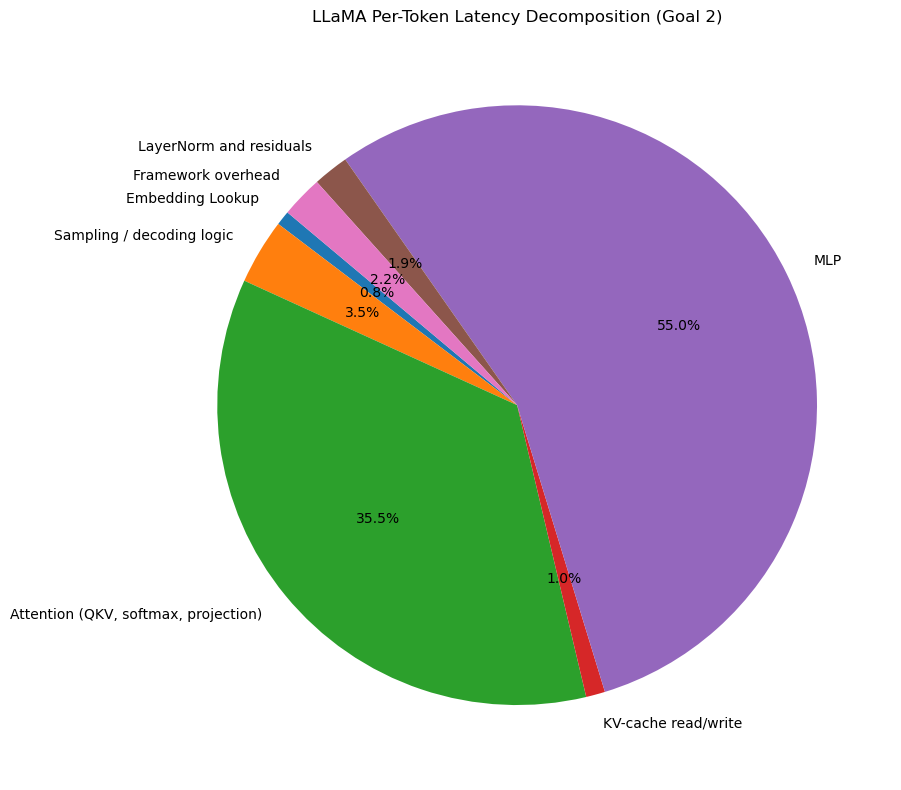

In [22]:
import matplotlib.pyplot as plt
from collections import defaultdict

def run_and_plot_goal_2(model, config, gen_length=20):
    """
    Goal 2: Forensic decomposition of LLaMA per-token latency.
    """
    model.eval()
    model.reset_timings() # Requires the instrumented LlamaModel class.
    sampling_times = []
    total_start = time.perf_counter()
    
    with torch.no_grad():
        input_ids = torch.randint(0, config.vocab_size, (1, 1)).to(config.device)
        for _ in range(gen_length):
            logits = model(input_ids)
            
            # --- Sampling / decoding logic timing ---
            ts_0 = time.perf_counter()
            _ = torch.argmax(logits[:, -1, :], dim=-1)
            sampling_times.append(time.perf_counter() - ts_0)
            
            # Use fixed input to simulate per-token steady state
            input_ids = torch.randint(0, config.vocab_size, (1, 1)).to(config.device)
    
    total_end = time.perf_counter()
    total_wall_clock = total_end - total_start
    
    # Aggregating data across all components
    final_data = defaultdict(float)
    final_data['Embedding Lookup'] = model.timings['embedding_lookup']
    final_data['Sampling / decoding logic'] = sum(sampling_times)
    
    for block in model.blocks:
        final_data['Attention (QKV, softmax, projection)'] += block.timings['attention']
        final_data['KV-cache read/write'] += block.timings['kv_cache_ops']
        final_data['MLP'] += block.timings['mlp']
        final_data['LayerNorm and residuals'] += block.timings['layernorm_residuals']

    # --- Framework overhead calculation ---
    # Calculated as the difference between total time and instrumented code.
    instrumented_sum = sum(final_data.values()) + model.timings['output_head']
    final_data['Framework overhead'] = max(0, total_wall_clock - instrumented_sum)

    # Visualizing for Report Quality
    plt.figure(figsize=(10, 8))
    plt.pie(final_data.values(), labels=final_data.keys(), autopct='%1.1f%%', startangle=140)
    plt.title('LLaMA Per-Token Latency Decomposition (Goal 2)')
    plt.tight_layout()
    plt.show()

# Execute Goal 2 Breakdown
# Ensure your model uses the instrumented LlamaBlock and LlamaModel classes.
run_and_plot_goal_2(model, config)